## MIT 6.7220/15.084 Nonlinear Optimization (Spring 2026)
## Alfredo Celedon Fuentes
## MITID: 970930309
## HW5

---
### Problem 1(a)

The first constraint,

$$
y_1^2+\frac{1}{3}y_2^2\leq 1,
$$

describes an ellipse centered at the origin.

The second constraint,

$$
y_1\geq \frac12,
$$

keeps only the part of the ellipse to the right of the vertical line

$$
y_1=\frac12.
$$

So $S$ is basically just the right-side tip of the ellipse.

Now, when we consider the objective

$$
x_1y_1+x_2y_2.
$$

This is the dot product between $x=(x_1,x_2)$ and $y=(y_1,y_2)$:

$$
x^\top y=x_1y_1+x_2y_2.
$$

For fixed $x$, maximizing this dot product means choosing the feasible point $y\in S$ that is most aligned with the direction of $x$. Basically we want the point in $S$ that goes farthest in the direction of $x$.

Equivalently, since the objective is linear in $y$, its level sets are lines of the form

$$
x_1y_1+x_2y_2=c.
$$

These lines are perpendicular to the vector $x$. As $c$ increases, the line shifts in the direction of $x$. Therefore, maximizing $x_1y_1+x_2y_2$ over $S$ means sliding this line in the direction of $x$ until it is about to leave the feasible set. The last point where it still touches $S$ is the optimizer.

This also explains how the solution depends on $x_1$ and $x_2$.

* If $x_2 \gt 0$, larger $y_2$ helps, so the optimizer is pushed upward.
* If $x_2 \lt 0$, smaller $y_2$ helps, so the optimizer is pushed downward.
* If $x_1$ is large relative to $\lvert x_2\rvert$, the optimizer is pushed more to the right.
* If $\lvert x_2\rvert$ is relatively large, the optimizer gets pushed toward the upper or lower end of the feasible set, and this is what eventually leads to the boundary $y_1=\frac12$ becoming binding.

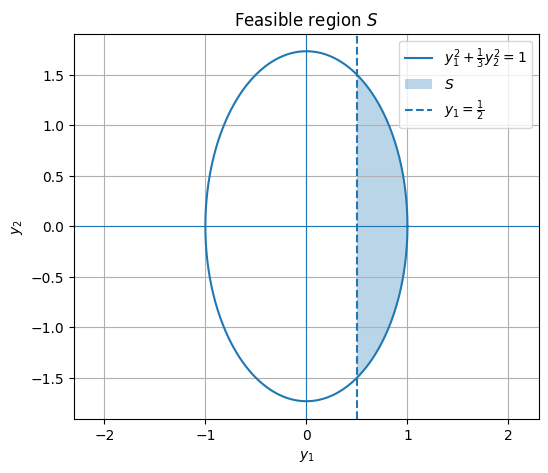

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create y1 values for the feasible cap: y1 ranges from 1/2 to 1
y1 = np.linspace(0.5, 1, 400)

# From the ellipse: y1^2 + (1/3)y2^2 <= 1
# Boundary implies y2 = ±sqrt(3(1 - y1^2))
y2_upper = np.sqrt(3 * (1 - y1**2))
y2_lower = -np.sqrt(3 * (1 - y1**2))

# Full ellipse boundary for reference
theta = np.linspace(0, 2*np.pi, 500)
ellipse_y1 = np.cos(theta)
ellipse_y2 = np.sqrt(3) * np.sin(theta)

plt.figure(figsize=(6, 5))

# Plot full ellipse boundary
plt.plot(ellipse_y1, ellipse_y2, label=r"$y_1^2+\frac{1}{3}y_2^2=1$")

# Fill feasible set S
plt.fill_between(y1, y2_lower, y2_upper, alpha=0.3, label=r"$S$")

# Plot line y1 = 1/2
plt.axvline(0.5, linestyle="--", label=r"$y_1=\frac{1}{2}$")

# Axes
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")
plt.title(r"Feasible region $S$")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

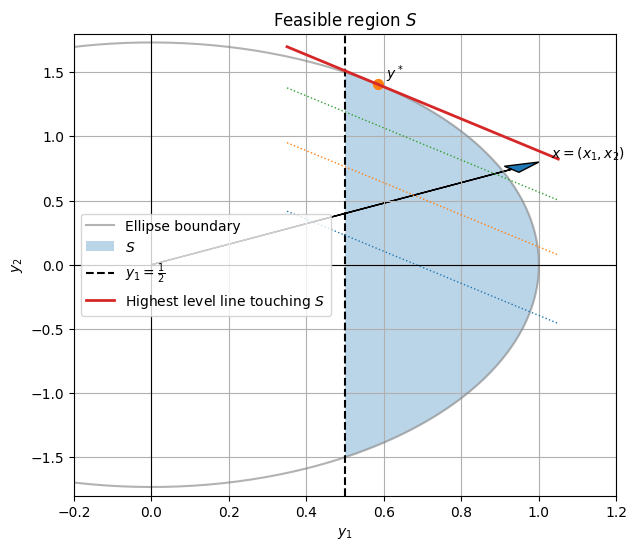

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Feasible set S
y1 = np.linspace(0.5, 1, 400)
y2_upper = np.sqrt(3 * (1 - y1**2))
y2_lower = -np.sqrt(3 * (1 - y1**2))

theta = np.linspace(0, 2*np.pi, 500)
ellipse_y1 = np.cos(theta)
ellipse_y2 = np.sqrt(3) * np.sin(theta)

# Choose one example direction x = (x1, x2)
x1, x2 = 1.0, 0.8

# Optimal point for this x
if abs(x2) <= x1:
    denom = np.sqrt(x1**2 + 3*x2**2)
    y1_star = x1 / denom
    y2_star = 3*x2 / denom
else:
    y1_star = 0.5
    if x2 > 0:
        y2_star = 1.5
    elif x2 < 0:
        y2_star = -1.5
    else:
        y2_star = 0.0

# Plot
plt.figure(figsize=(7, 6))

# Full ellipse + feasible set
plt.plot(ellipse_y1, ellipse_y2, color="gray", alpha=0.6, label=r"Ellipse boundary")
plt.fill_between(y1, y2_lower, y2_upper, alpha=0.3, label=r"$S$")
plt.axvline(0.5, linestyle="--", color="black", label=r"$y_1=\frac{1}{2}$")

# Vector x
plt.arrow(0, 0, x1, x2, head_width=0.06, length_includes_head=True)
plt.text(x1 + 0.03, x2 + 0.03, r"$x=(x_1,x_2)$")

# Level lines x1*y1 + x2*y2 = c
yy1 = np.linspace(0.35, 1.05, 200)

# Optimal c
c_star = x1 * y1_star + x2 * y2_star

# A few level lines before the optimal one
for c in [0.4 * c_star, 0.65 * c_star, 0.85 * c_star]:
    yy2 = (c - x1 * yy1) / x2
    plt.plot(yy1, yy2, linestyle=":", linewidth=1)

# Supporting level line at the optimum
yy2_star_line = (c_star - x1 * yy1) / x2
plt.plot(yy1, yy2_star_line, linewidth=2, label=r"Highest level line touching $S$")

# Optimal point
plt.scatter(y1_star, y2_star, s=50)
plt.text(y1_star + 0.02, y2_star + 0.05, r"$y^*$")

plt.xlim(-0.2, 1.2)
plt.ylim(-1.8, 1.8)
plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")
plt.title(r"Feasible region $S$")
plt.axhline(0, linewidth=0.8, color="black")
plt.axvline(0, linewidth=0.8, color="black")
plt.grid(True)
plt.legend()
plt.show()

---

### Problem 1(b)

$$
(P)\qquad
\max_{y_1,y_2} x_1y_1+x_2y_2
$$

s.t.

$$
y_1^2+\frac{1}{3}y_2^2\leq 1.
$$

The constraint is an ellipse, so I transformed it into a unit circle by defining

$$
u_1=y_1,
\qquad
u_2=\frac{y_2}{3^{1/2}}.
$$

Then

$$
y_1=u_1,
\qquad
y_2=u_2 3^{1/2}.
$$

Substituting this into the constraint gives

$$
u_1^2+u_2^2\leq 1.
$$

So now the problem is the same as maximizing over the unit disk.

Then I rewrite the objective using $u_1$ and $u_2$:

$$
x_1y_1+x_2y_2
=
x_1u_1+x_2(3^{1/2}u_2).
$$
$$
x_1y_1+x_2y_2
=
x_1u_1+3^{1/2}x_2u_2.
$$

Which is the dot product between $(x_1,3^{1/2}x_2)$ and $(u_1,u_2)$:

$$
x_1u_1+3^{1/2}x_2u_2
=
(x_1,3^{1/2}x_2)^\top (u_1,u_2).
$$

Since $(u_1,u_2)$ must lie inside the unit disk, this dot product is maximized when $(u_1,u_2)$ points in the same direction as $(x_1,3^{1/2}x_2)$. Then I use Cauchy-Schwarz,

$$
x_1u_1+3^{1/2}x_2u_2
\leq
(x_1^2+3x_2^2)^{1/2}(u_1^2+u_2^2)^{1/2}.
$$

Because

$$
u_1^2+u_2^2\leq 1,
$$

we get

$$
x_1u_1+3^{1/2}x_2u_2
\leq
(x_1^2+3x_2^2)^{1/2}.
$$

Then the upper bound is achieved when

$$
(u_1,u_2)
=
\frac{(x_1,3^{1/2}x_2)}{(x_1^2+3x_2^2)^{1/2}}.
$$

Therefore,

$$
u_1^*
=
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}},
\qquad
u_2^*
=
\frac{3^{1/2}x_2}{(x_1^2+3x_2^2)^{1/2}}.
$$

Now I substitute back to the original $y$ variables.

$$
y_1=u_1,
\qquad
y_2=3^{1/2}u_2,
$$

I get

$$
\tilde y_1
=
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}},
$$

and

$$
\tilde y_2
=
\frac{3x_2}{(x_1^2+3x_2^2)^{1/2}}.
$$

So the unique optimizer, when $(x_1,x_2)\neq (0,0)$, is

$$
\tilde y
=
\left(
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}},
\frac{3x_2}{(x_1^2+3x_2^2)^{1/2}}
\right).
$$

The optimal value is

$$
x_1\tilde y_1+x_2\tilde y_2.
$$

Substituting the optimizer,

$$
x_1\tilde y_1+x_2\tilde y_2
=
x_1\left(\frac{x_1}{(x_1^2+3x_2^2)^{1/2}}\right)
+
x_2\left(\frac{3x_2}{(x_1^2+3x_2^2)^{1/2}}\right).
$$

Thus,

$$
x_1\tilde y_1+x_2\tilde y_2
=
\frac{x_1^2+3x_2^2}{(x_1^2+3x_2^2)^{1/2}}
=
(x_1^2+3x_2^2)^{1/2}.
$$

The optimizer is unique for $(x_1,x_2)\neq (0,0)$ because the dot product is maximized only when $(u_1,u_2)$ points in the same direction as $(x_1,3^{1/2}x_2)$.

If $(x_1,x_2)=(0,0)$, then the objective is always zero, so every feasible point is optimal. Therefore, uniqueness fails only at the origin.

---
### Problem 1(c)

From part (b), for $(x_1,x_2)\neq (0,0)$, we have that the optimizer of the relaxed problem is

$$
\tilde y_1
=
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}},
\qquad
\tilde y_2
=
\frac{3x_2}{(x_1^2+3x_2^2)^{1/2}}.
$$

Now assuming

$$
\tilde y_1\geq \frac12.
$$

Substituting the expression for $\tilde y_1$, this means

$$
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}}\geq \frac12.
$$

Since the denominator is positive, this first implies

$$
x_1\geq 0.
$$

Then I multiply both sides by the denominator:

$$
2x_1\geq (x_1^2+3x_2^2)^{1/2}.
$$

$$
4x_1^2\geq x_1^2+3x_2^2.
$$

$$
3x_1^2\geq 3x_2^2.
$$

$$
x_1^2\geq x_2^2.
$$

Since $x_1\geq 0$, this is equivalent to

$$
\lvert x_2\rvert \leq x_1.
$$

Therefore, the condition $\tilde y_1\geq 1/2$ corresponds to

$$
\lvert x_2\rvert \leq x_1.
$$

In this case, since the relaxed optimizer already satisfies the extra constraint $y_1\geq 1/2$, the solution is also the optimizer of the original problem over $S$.

So the optimal solution is

$$
y^*
=
\left(
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}},
\frac{3x_2}{(x_1^2+3x_2^2)^{1/2}}
\right).
$$

The corresponding optimal objective value is

$$
x_1y_1^*+x_2y_2^*
=
(x_1^2+3x_2^2)^{1/2}.
$$

So in the case $\lvert x_2\rvert \leq x_1$, we get the first branch of $f$:

$$
f(x_1,x_2)=(x_1^2+3x_2^2)^{1/2}.
$$

---
### Problem 1(d)

Now when

$$
\tilde y_1 \lt \frac12.
$$

From part (c), the case $\tilde y_1\geq 1/2$ corresponds to

$$
\lvert x_2\rvert \leq x_1.
$$

Therefore, the case $\tilde y_1 \lt 1/2$ corresponds to

$$
\lvert x_2\rvert \gt x_1.
$$

In this case, the optimizer from the relaxed ellipse problem is not feasible for the original problem because it violates

$$
y_1\geq \frac12.
$$

So the constraint must bind, meaning the optimal solution must have

$$
y_1^*=\frac12.
$$

Knowing this I substitute $y_1=1/2$ into the ellipse constraint:

$$
y_1^2+\frac13 y_2^2\leq 1.
$$

$$
\left(\frac12\right)^2+\frac13 y_2^2\leq 1.
$$

$$
\frac14+\frac13 y_2^2\leq 1.
$$

$$
\frac13 y_2^2\leq \frac34.
$$

$$
y_2^2\leq \frac94.
$$

Therefore,

$$
-\frac32\leq y_2\leq \frac32.
$$

Since $y_1^*=1/2$, the problem becomes choosing $y_2$ to maximize

$$
x_1\left(\frac12\right)+x_2y_2.
$$

The first term is fixed, so I only need to choose $y_2$ depending on the sign of $x_2$.

If $x_2\gt 0$, then larger $y_2$ increases the objective, so

$$
y_2^*=\frac32.
$$

If $x_2\lt 0$, then smaller $y_2$ increases the objective, so

$$
y_2^*=-\frac32.
$$

Therefore, when $x_2\neq 0$,

$$
y_2^*=\frac32\operatorname{sign}(x_2).
$$

The optimal value is then

$$
x_1y_1^*+x_2y_2^*
=
x_1\left(\frac12\right)
+
x_2\left(\frac32\operatorname{sign}(x_2)\right).
$$

Since

$$
x_2\operatorname{sign}(x_2)=\lvert x_2\rvert,
$$

we get

$$
x_1y_1^*+x_2y_2^*
=
\frac{x_1}{2}+\frac{3}{2}\lvert x_2\rvert.
$$

Therfore,

$$
x_1y_1^*+x_2y_2^*
=
\frac{x_1+3\lvert x_2\rvert}{2}.
$$

Now I also need to consider the case $x_2=0$. In this case, the objective becomes

$$
x_1y_1.
$$

Since we are in the case $\tilde y_1\lt 1/2$, this means $x_1\lt 0$. Therefore, to maximize $x_1y_1$, I want the smallest feasible value of $y_1$, which is

$$
y_1^*=\frac12.
$$

When $y_1=1/2$, any

$$
y_2\in\left[-\frac32,\frac32\right]
$$

is optimal because $x_2y_2=0$.

The optimal value is

$$
x_1\left(\frac12\right)
=
\frac{x_1}{2}.
$$

This is consistent with

$$
\frac{x_1+3\lvert x_2\rvert}{2},
$$

because $x_2=0$.

Therefore, in the case $\tilde y_1\lt 1/2$, the optimal value of the original problem is

$$
\frac{x_1+3\lvert x_2\rvert}{2}.
$$

Combining this with part (c), I get that

$$
f(x_1,x_2)
=
\begin{cases}
(x_1^2+3x_2^2)^{1/2}, & \lvert x_2\rvert \leq x_1,\\[6pt]
\dfrac{x_1+3\lvert x_2\rvert}{2}, & \text{otherwise}.
\end{cases}
$$

So $f(x_1,x_2)$ is exactly the value function of problem (2).

---
### Problem 1(e)

From the previous parts, we have that

$$
f(x_1,x_2)
=
\max_{(y_1,y_2)\in S}
x_1y_1+x_2y_2.
$$

For any fixed feasible point $y=(y_1,y_2)\in S$, the function

$$
x_1y_1+x_2y_2
$$

is linear in $x=(x_1,x_2)$.

Since linear functions are convex, each function

$$
x\mapsto x^\top y
$$

is convex.

Then $f$ is the pointwise maximum of these linear functions:

$$
f(x)
=
\max_{y\in S} x^\top y.
$$

The pointwise maximum of convex functions is convex, making $f$ convex.

To show this directly, take any two points $x,z\in\mathbb{R}^2$ and any $\lambda\in[0,1]$. Then

$$
f(\lambda x+(1-\lambda)z)
=
\max_{y\in S}(\lambda x+(1-\lambda)z)^\top y.
$$

Expanding the dot product,

$$
f(\lambda x+(1-\lambda)z)
=
\max_{y\in S}
\left[
\lambda x^\top y+(1-\lambda)z^\top y
\right].
$$

For every $y\in S$,

$$
x^\top y\leq f(x)
$$

and

$$
z^\top y\leq f(z).
$$

Therefore,

$$
\lambda x^\top y+(1-\lambda)z^\top y
\leq
\lambda f(x)+(1-\lambda)f(z).
$$

Since this is true for every $y\in S$, it is also true for the maximum over $S$. Therefore:

$$
f(\lambda x+(1-\lambda)z)
\leq
\lambda f(x)+(1-\lambda)f(z).
$$

This is exactly the definition of convexity, so $f$ is convex on $\mathbb{R}^2$.



---
### Problem 2(a)

Prove

$$
\partial f(x_1,x_2)\subseteq A(x_1,x_2),
$$

where

$$
A(x_1,x_2)
=
\arg\max_{(y_1,y_2)\in S}
x_1y_1+x_2y_2.
$$

From Problem 1, we have that

$$
f(x)=\max_{y\in S} x^\top y.
$$

Now taking any

$$
g\in \partial f(x).
$$

By the definition of subgradient, for every $z\in\mathbb{R}^2$,

$$
f(z)\geq f(x)+g^\top(z-x).
$$

Now to show that $g\in A(x)$ I need to show that $g\in S$ and that $g$ attains the maximum value in the definition of $f(x)$.

First, I set $z=0$. Since $f(0)=0$, the subgradient inequality gives

$$
0\geq f(x)+g^\top(0-x).
$$

$$
0\geq f(x)-g^\top x.
$$

$$
g^\top x\geq f(x).
$$

Now setting $z=2x$. Since $f$ is positively homogeneous,

$$
f(2x)=2f(x).
$$

Then the subgradient inequality gives

$$
2f(x)\geq f(x)+g^\top(2x-x).
$$

$$
2f(x)\geq f(x)+g^\top x.
$$

$$
f(x)\geq g^\top x.
$$

Combining both inequalities,

$$
g^\top x=f(x).
$$

Now to show that $g\in S$, using the subgradient inequality again,

$$
f(z)\geq f(x)+g^\top(z-x).
$$

Since $g^\top x=f(x)$, this becomes

$$
f(z)\geq g^\top z
$$

for every $z\in\mathbb{R}^2$.

But from Problem 1,

$$
f(z)=\max_{y\in S}z^\top y.
$$

Therefore,

$$
g^\top z\leq \max_{y\in S}z^\top y
\qquad
\text{for every } z.
$$

This means that $g$ cannot lie outside $S$. If $g\notin S$, then since $S$ is closed and convex, there would be a direction $z$ that separates $g$ from $S$, meaning

$$
g^\top z>\max_{y\in S}y^\top z.
$$

But this contradicts

$$
g^\top z\leq \max_{y\in S}z^\top y.
$$

So

$$
g\in S.
$$

Now we have

$$
g\in S
$$

and

$$
g^\top x=f(x).
$$

Since

$$
f(x)=\max_{y\in S}x^\top y,
$$

the equality $g^\top x=f(x)$ means that $g$ is one of the maximizers over $S$.

Therefore,

$$
g\in A(x).
$$

Since this holds for any $g\in \partial f(x)$,

$$
\partial f(x)\subseteq A(x).
$$

---

### Problem 2(b)

From part 2(a), we can use

$$
\partial f(x_1,x_2)
=
\arg\max_{(y_1,y_2)\in S}
x_1y_1+x_2y_2.
$$

So to find the subdifferential, I just need to write down the set of optimal solutions of the maximization problem over $S$.

We have:

$$
S=
\left\{
(y_1,y_2):
y_1^2+\frac13y_2^2\leq 1,
\quad
y_1\geq \frac12
\right\}.
$$

#### Case 1: $x_1=x_2=0$

If

$$
x_1=x_2=0,
$$

then the objective is

$$
x_1y_1+x_2y_2=0
$$

for every feasible point $(y_1,y_2)\in S$.

Therefore, every feasible point is optimal:

$$
\partial f(0,0)=S.
$$

Which is the same as:

$$
\partial f(0,0)
=
\left\{
(y_1,y_2):
y_1^2+\frac13y_2^2\leq 1,
\quad
y_1\geq \frac12
\right\}.
$$

#### Case 2: $\lvert x_2\rvert \leq x_1$, with $x_1\neq 0$

In this case, the solution from the relaxed ellipse problem already satisfies

$$
y_1\geq \frac12.
$$

So the extra constraint does not change the optimizer.

From part 1(b), the optimizer is

$$
\tilde y
=
\left(
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}},
\frac{3x_2}{(x_1^2+3x_2^2)^{1/2}}
\right).
$$

Therefore,

$$
\partial f(x_1,x_2)
=
\left\{
\left(
\frac{x_1}{(x_1^2+3x_2^2)^{1/2}},
\frac{3x_2}{(x_1^2+3x_2^2)^{1/2}}
\right)
\right\}.
$$

This is a singleton, so $f$ is differentiable in this case.

#### Case 3: $\lvert x_2\rvert \gt x_1$, with $x_2\neq 0$

In this case, the relaxed optimizer violates the constraint

$$
y_1\geq \frac12.
$$

So the constraint binds:

$$
y_1^*=\frac12.
$$

Then the ellipse constraint gives

$$
-\frac32\leq y_2\leq \frac32.
$$

And the objective becomes

$$
x_1\left(\frac12\right)+x_2y_2.
$$

Since $x_2\neq 0$, the optimal $y_2$ is one of the endpoints.

If $x_2\gt 0$, then

$$
y_2^*=\frac32.
$$

If $x_2\lt 0$, then

$$
y_2^*=-\frac32.
$$

So I can write

$$
y_2^*=\frac32\operatorname{sign}(x_2).
$$

Therefore,

$$
\partial f(x_1,x_2)
=
\left\{
\left(
\frac12,
\frac32\operatorname{sign}(x_2)
\right)
\right\}.
$$

Again, this is a singleton, so $f$ is differentiable in this case.


#### Case 4: $x_2=0$, with $x_1\lt 0$

Now the objective is

$$
x_1y_1.
$$

Since $x_1\lt 0$, maximizing $x_1y_1$ means choosing the smallest feasible value of $y_1$.

Because $S$ requires

$$
y_1\geq \frac12,
$$

we must have

$$
y_1^*=\frac12.
$$

Once $y_1=1/2$, the ellipse constraint gives

$$
-\frac32\leq y_2\leq \frac32.
$$

Since $x_2=0$, the objective does not depend on $y_2$. Therefore, every value of $y_2$ in this interval is optimal.

Thus,

$$
\partial f(x_1,0)
=
\left\{
\left(\frac12,y_2\right):
-\frac32\leq y_2\leq \frac32
\right\},
\qquad x_1\lt 0.
$$

When put all these cases together we obtain the following:

$$
\partial f(x_1,x_2)
=
\begin{cases}
S,
& x_1=x_2=0,
\\[8pt]
\left\{
\left(
\dfrac{x_1}{(x_1^2+3x_2^2)^{1/2}},
\dfrac{3x_2}{(x_1^2+3x_2^2)^{1/2}}
\right)
\right\},
& \lvert x_2\rvert \leq x_1,\ x_1\neq 0,
\\[14pt]
\left\{
\left(
\dfrac12,
\dfrac32\operatorname{sign}(x_2)
\right)
\right\},
& \lvert x_2\rvert \gt x_1,\ x_2\neq 0,
\\[14pt]
\left\{
\left(\dfrac12,y_2\right):
-\dfrac32\leq y_2\leq \dfrac32
\right\},
& x_2=0,\ x_1\lt 0.
\end{cases}
$$

---

### Problem 3(a)

Assuming that the current iterate satisfies

$$
\lvert x_2^{(t)}\rvert \leq x_1^{(t)},
\qquad
x_1^{(t)}\neq 0.
$$

From Problem 2(b), in this region the subdifferential is a singleton:

$$
\partial f(x_1^{(t)},x_2^{(t)})
=
\left\{
\left(
\frac{x_1^{(t)}}{\left((x_1^{(t)})^2+3(x_2^{(t)})^2\right)^{1/2}},
\frac{3x_2^{(t)}}{\left((x_1^{(t)})^2+3(x_2^{(t)})^2\right)^{1/2}}
\right)
\right\}.
$$

Since the subdifferential contains only one vector, $f$ is differentiable at this point.

Therefore,

$$
\nabla f(x_1^{(t)},x_2^{(t)})
=
\left(
\frac{x_1^{(t)}}{D_t},
\frac{3x_2^{(t)}}{D_t}
\right),
$$

where

$$
D_t=
\left((x_1^{(t)})^2+3(x_2^{(t)})^2\right)^{1/2}.
$$



---

### Problem 3(b)

Let

$$
a=x_1^{(t)},
\qquad
b=x_2^{(t)},
\qquad
D=\left(a^2+3b^2\right)^{1/2}.
$$

From part (a) we have,

$$
\nabla f(a,b)
=
\left(
\frac{a}{D},
\frac{3b}{D}
\right).
$$

The line-search path is

$$
(a,b)-h\nabla f(a,b).
$$

So the new coordinates as a function of $h$ are

$$
u(h)=a-\frac{ha}{D}
=
a\left(1-\frac{h}{D}\right),
$$

$$
v(h)=b-\frac{3hb}{D}
=
b\left(1-\frac{3h}{D}\right).
$$

Therefore,

$$
g(h)=f(u(h),v(h)).
$$

While the line-search point remains in the smooth region, we have

$$
g(h)
=
\left(u(h)^2+3v(h)^2\right)^{1/2}.
$$

Substituting $u(h)$ and $v(h)$ we get:

$$
g(h)
=
\left[
a^2\left(1-\frac{h}{D}\right)^2
+
3b^2\left(1-\frac{3h}{D}\right)^2
\right]^{1/2}.
$$

Then I differentiate:

$$
g'(h)
=
\frac{
-\frac{a^2}{D}\left(1-\frac{h}{D}\right)
-\frac{9b^2}{D}\left(1-\frac{3h}{D}\right)
}{
\left[
a^2\left(1-\frac{h}{D}\right)^2
+
3b^2\left(1-\frac{3h}{D}\right)^2
\right]^{1/2}
}.
$$

$$
g'(h)
=
-\frac{
a^2\left(1-\frac{h}{D}\right)
+
9b^2\left(1-\frac{3h}{D}\right)
}{
D\left[
a^2\left(1-\frac{h}{D}\right)^2
+
3b^2\left(1-\frac{3h}{D}\right)^2
\right]^{1/2}
}.
$$



---

### Problem 3(c)

Now assuming iteration t is

$$
x_1^{(t)}=3\left(\frac12\right)^t,
\qquad
x_2^{(t)}=\left(-\frac12\right)^t.
$$

Define

$$
q=\left(\frac12\right)^t.
$$

Then

$$
a=3q,
\qquad
b=(-1)^t q.
$$

So

$$
D
=
(a^2+3b^2)^{1/2}
=
(9q^2+3q^2)^{1/2}
=
(12q^2)^{1/2}
=
2(3)^{1/2}q.
$$

The proposed step size is

$$
h=(3)^{1/2}\left(\frac12\right)^t
=
(3)^{1/2}q.
$$

Therefore,

$$
\frac{h}{D}
=
\frac{(3)^{1/2}q}{2(3)^{1/2}q}
=
\frac12.
$$

Using the expression for $g'(h)$ from part (b), the numerator is

$$
a^2\left(1-\frac{h}{D}\right)
+
9b^2\left(1-\frac{3h}{D}\right).
$$

Substituting $\frac{h}{D}=1/2$,

$$
a^2\left(1-\frac12\right)
+
9b^2\left(1-\frac32\right).
$$

Since

$$
a^2=9q^2,
\qquad
b^2=q^2,
$$

this becomes

$$
9q^2\left(\frac12\right)
+
9q^2\left(-\frac12\right)
=
0.
$$

Therefore,

$$
g'\left((3)^{1/2}\left(\frac12\right)^t\right)=0.
$$

Since $g(h)$ is convex in $h$, having derivative equal to zero means this is the exact line-search minimizer. Therefore,

$$
h_t=(3)^{1/2}\left(\frac12\right)^t.
$$

---

### Problem 3(d)

Now I complete the induction.

The gradient at iteration $t$ is

$$
\nabla f(x^{(t)})
=
\left(
\frac{x_1^{(t)}}{D},
\frac{3x_2^{(t)}}{D}
\right).
$$

Using

$$
x_1^{(t)}=3q,
\qquad
x_2^{(t)}=(-1)^t q,
\qquad
D=2\sqrt{3}q,
$$

we get

$$
\nabla f(x^{(t)})
=
\left(
\frac{3q}{2\sqrt{3}q},
\frac{3(-1)^t q}{2\sqrt{3}q}
\right).
$$

$$
\nabla f(x^{(t)})
=
\left(
\frac{\sqrt{3}}{2},
\frac{(-1)^t\sqrt{3}}{2}
\right).
$$

From part (c),

$$
h_t=\sqrt{3}q.
$$

Therefore,

$$
x^{(t+1)}
=
x^{(t)}-h_t\nabla f(x^{(t)}).
$$

For the first coordinate,

$$
x_1^{(t+1)}
=
3q-\sqrt{3}q\left(\frac{\sqrt{3}}{2}\right)
=
3q-\frac{3q}{2}
=
\frac{3q}{2}.
$$

Since $q=(1/2)^t$,

$$
x_1^{(t+1)}
=
3\left(\frac12\right)^{t+1}.
$$

For the second coordinate,

$$
x_2^{(t+1)}
=
(-1)^tq-\sqrt{3}q\left(\frac{(-1)^t\sqrt{3}}{2}\right).
$$

So

$$
x_2^{(t+1)}
=
(-1)^tq-\frac{3(-1)^tq}{2}
=
-\frac{(-1)^tq}{2}.
$$

Therefore,

$$
x_2^{(t+1)}
=
(-1)^{t+1}\left(\frac12\right)^{t+1}
=
\left(-\frac12\right)^{t+1}.
$$

Thus,

$$
x^{(t+1)}
=
\left(
3\left(\frac12\right)^{t+1},
\left(-\frac12\right)^{t+1}
\right).
$$

This completes the induction.



---

### Problem 3(e)

Starting from

$$
x^{(0)}=(3,1),
$$

the iterates are

$$
x^{(t)}
=
\left(
3\left(\frac12\right)^t,
\left(-\frac12\right)^t
\right).
$$

Taking the limit as $t\to\infty$,

$$
3\left(\frac12\right)^t\to 0
$$

and

$$
\left(-\frac12\right)^t\to 0.
$$

Therefore, GD-LS converges to

$$
x^*=(0,0).
$$



---

### Problem 3(f)

Now I show that

$$
x^*=(0,0)
$$

is not a global minimum.

At the limit point,

$$
f(0,0)=0.
$$

But if I choose a point like

$$
(-1,0),
$$

then this falls in the second branch of $f$, because

$$
\lvert 0\rvert \leq -1
$$

is false.

Therefore,

$$
f(-1,0)
=
\frac{-1+3\lvert 0\rvert}{2}
=
-\frac12.
$$

So

$$
f(-1,0)\lt f(0,0).
$$

Therefore, $(0,0)$ is not a global minimum.

In fact, if we take

$$
x_1\to -\infty,
\qquad
x_2=0,
$$

then

$$
f(x_1,0)=\frac{x_1}{2}\to -\infty.
$$

So the original function is not bounded below.

---

### Problem 3(g)

The plot shows that the GD-LS iterates stay inside the smooth region

$$
\lvert x_2\rvert \leq x_1.
$$

They approach the origin while alternating signs in the second coordinate. Therefore, every iterate is in a region where $f$ is differentiable, but the method still converges to $(0,0)$, which is not a global minimum.

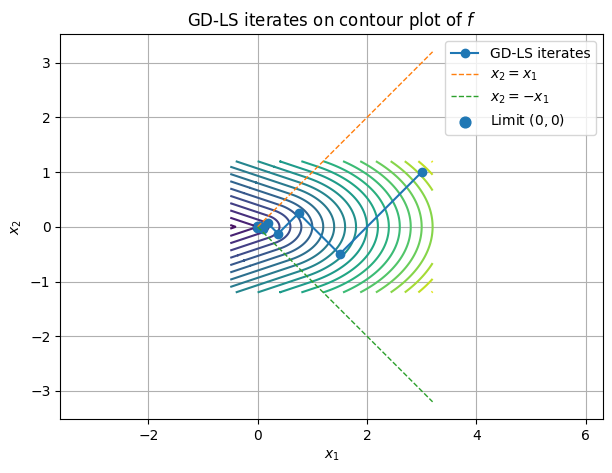

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x1, x2):
    smooth_region = np.abs(x2) <= x1
    smooth_value = np.sqrt(x1**2 + 3*x2**2)
    linear_value = (x1 + 3*np.abs(x2)) / 2
    return np.where(smooth_region, smooth_value, linear_value)

# Grid for contour plot
x1 = np.linspace(-0.5, 3.2, 400)
x2 = np.linspace(-1.2, 1.2, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

# GD-LS iterates from the formula
T = 12
t = np.arange(T + 1)
iter_x1 = 3 * (0.5)**t
iter_x2 = (-0.5)**t

plt.figure(figsize=(7, 5))

plt.contour(X1, X2, Z, levels=25)
plt.plot(iter_x1, iter_x2, marker="o", label="GD-LS iterates")

# Smooth-region boundaries: x2 = x1 and x2 = -x1
boundary_x = np.linspace(0, 3.2, 200)
plt.plot(boundary_x, boundary_x, linestyle="--", linewidth=1, label=r"$x_2=x_1$")
plt.plot(boundary_x, -boundary_x, linestyle="--", linewidth=1, label=r"$x_2=-x_1$")

plt.scatter([0], [0], s=60, label=r"Limit $(0,0)$")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("GD-LS iterates on contour plot of $f$")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

---

## Problem 4

In this problem, we move from gradient descent with exact line search to the subgradient method.

The original function is not bounded below because if we take $x_2=0$ and let $x_1\to -\infty$, then

$$
f(x_1,0)=\frac{x_1}{2}\to -\infty.
$$

So the problem defines the clipped function

$$
\tilde f(x_1,x_2)=\max\{f(x_1,x_2),-1\}.
$$

Now the minimum value is

$$
\tilde f^*=-1.
$$

The first code cell defines helper functions. Specifically, it defines:

* the original function $f$,
* the clipped function $\tilde f$,
* one valid subgradient of $f$ using the cases from Problem 2(b),
* one valid subgradient of $\tilde f$.

The main idea is that when $f(x)>-1$, the clipped function behaves like $f$. When $f(x)\leq -1$, the clipped function is flat, so I choose the subgradient $g=0$.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f_value(x):
    x1, x2 = x

    if abs(x2) <= x1:
        return (x1**2 + 3*x2**2)**0.5

    return (x1 + 3*abs(x2)) / 2


def f_tilde_value(x):
    return max(f_value(x), -1)


def subgrad_f(x):
    x1, x2 = x

    # At the origin, any point in S is valid. I choose (1, 0).
    if abs(x1) < 1e-12 and abs(x2) < 1e-12:
        return np.array([1.0, 0.0])

    # Smooth region
    if abs(x2) <= x1 and x1 != 0:
        d = (x1**2 + 3*x2**2)**0.5
        return np.array([x1 / d, 3*x2 / d])

    # Linear region with x2 != 0
    if x2 > 0:
        return np.array([0.5, 1.5])

    if x2 < 0:
        return np.array([0.5, -1.5])

    # Case x2 = 0 and x1 < 0
    return np.array([0.5, 0.0])


def subgrad_f_tilde(x):
    if f_value(x) <= -1:
        return np.array([0.0, 0.0])

    return subgrad_f(x)

---

### Problem 4(a)

For part (a), I implement the normalized subgradient method with constant step size:

$$
x_{t+1}
=
x_t-h\frac{g_t}{\lVert g_t\rVert},
\qquad
g_t\in \partial \tilde f(x_t).
$$

The lecture notes suggest using

$$
h=\frac{\lVert x_0-x^*\rVert}{(T+1)^{1/2}},
$$

but we do not know $x^*$. So instead I use an estimate $D$ and set

$$
h=\frac{D}{(T+1)^{1/2}}.
$$

I start at

$$
x^{(0)}=(3,1)
$$

and run the method until

$$
T=100.
$$

I try three different values of $D$ to see how the step-size estimate changes the behavior. For each run, I plot

$$
\min_{0\leq i\leq t}\tilde f(x_i)
$$

over time.

From my results, the iterates do not get stuck at $(0,0)$. They continue making progress past the value $\tilde f(0,0)=0$.

For $D=0.5$, the step size is smaller, so the method progresses slowly and only reaches a best value of about $-0.274$ after 100 iterations. For $D=1.0$, the method reaches the clipped optimum value $\tilde f=-1$ at iteration 97. For $D=3.0$, it reaches $\tilde f=-1$ much faster, at iteration 32.

So the subgradient method makes further progress. The estimate of $D$ matters because it controls the step size: smaller $D$ gives slower but more conservative progress, while larger $D$ moves faster toward the clipped optimal region.

D = 0.5
  final x = [-5.47151130e-01 -3.32325355e-06]
  final best value = -0.273571
  first time reaching -1 = not reached

D = 1.0
  final x = [-2.02285334e+00 -8.50405023e-06]
  final best value = -1.000000
  first time reaching -1 = 97

D = 3.0
  final x = [-2.18158984 -0.00898045]
  final best value = -1.000000
  first time reaching -1 = 32



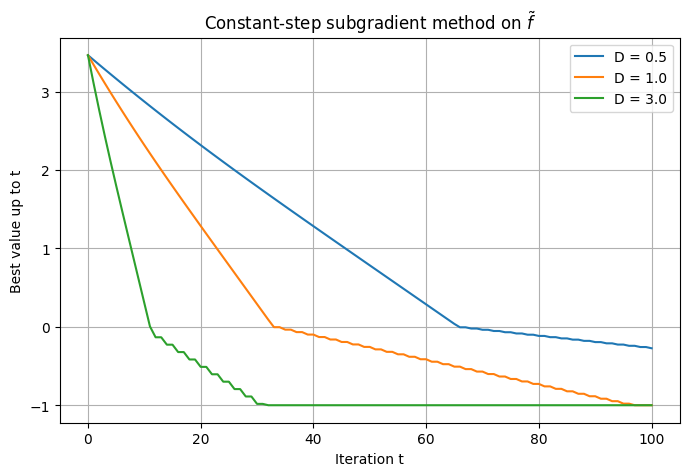

In [7]:
def run_constant_step(D_estimate, T=100, x0=np.array([3.0, 1.0])):
    h = D_estimate / np.sqrt(T + 1)

    xs = [x0.copy()]
    values = [f_tilde_value(x0)]

    for _ in range(T):
        x = xs[-1].copy()
        g = subgrad_f_tilde(x)
        norm_g = np.linalg.norm(g)

        if norm_g > 0:
            x = x - h * g / norm_g

        xs.append(x)
        values.append(f_tilde_value(x))

    xs = np.array(xs)
    values = np.array(values)
    best_values = np.minimum.accumulate(values)

    return xs, values, best_values


T = 100
D_estimates = [0.5, 1.0, 3.0]

plt.figure(figsize=(8, 5))

for D in D_estimates:
    xs, values, best_values = run_constant_step(D, T)

    plt.plot(best_values, label=f"D = {D}")

    first_hit = np.where(best_values <= -1 + 1e-10)[0]
    first_hit_text = first_hit[0] if len(first_hit) > 0 else "not reached"

    print(f"D = {D}")
    print(f"  final x = {xs[-1]}")
    print(f"  final best value = {best_values[-1]:.6f}")
    print(f"  first time reaching -1 = {first_hit_text}")
    print()

plt.xlabel("Iteration t")
plt.ylabel(r"Best value up to t")
plt.title(r"Constant-step subgradient method on $\tilde f$")
plt.grid(True)
plt.legend()
plt.show()

---

### Problem 4(b)

For part (b), I implement the subgradient method with Polyak's step size:

$$
x_{t+1}=x_t-h_tg_t,
$$

where

$$
h_t=
\frac{\tilde f(x_t)-\tilde f^*}{\lVert g_t\rVert^2}
$$

when $g_t\neq 0$.

Since

$$
\tilde f(x_1,x_2)=\max\{f(x_1,x_2),-1\},
$$

the function can never go below $-1$. Also, this value is attainable. For example,

$$
f(-2,0)=-1.
$$

Therefore,

$$
\tilde f^*=-1.
$$

So the Polyak step size becomes

$$
h_t=
\frac{\tilde f(x_t)+1}{\lVert g_t\rVert^2}.
$$

The first plot shows the best optimality gap so far,

$$
\min_{1\leq i\leq t}\tilde f(x_i)-\tilde f^*.
$$

The second plot shows the actual paths of the constant-step and Polyak methods on the contour plot of $\tilde f$, which helps visualize whether the subgradient method get stuck at $(0,0)$.

From the output, the Polyak method finishes with

$$
\tilde f(x_T)\approx -1
$$

and the final best gap is approximately

$$
5.43\times 10^{-10}.
$$

This means the method essentially reaches the optimal clipped value. The first plot confirms this: the best gap drops quickly toward zero and stays there. Since

$$
\tilde f^*=-1,
$$

a gap close to zero means the iterates have reached the region where $\tilde f(x)=-1$.

The trajectory plot also shows that the method does not get stuck at $(0,0)$. Instead, the path moves past the origin and continues toward the flat clipped region on the left side of the plot. This is different from GD-LS in Problem 3, which converged to $(0,0)$ even though it was not globally optimal.

tilde f* = -1
final x = [-2.00000000e+00  1.81124272e-10]
final value = -0.9999999995
final best gap = 5.4337290223e-10


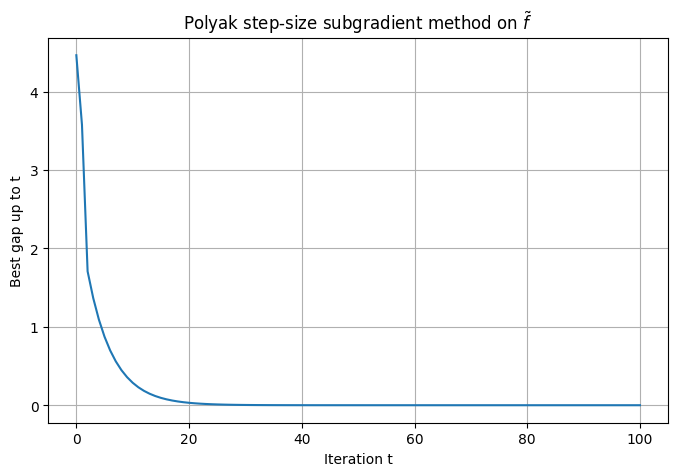

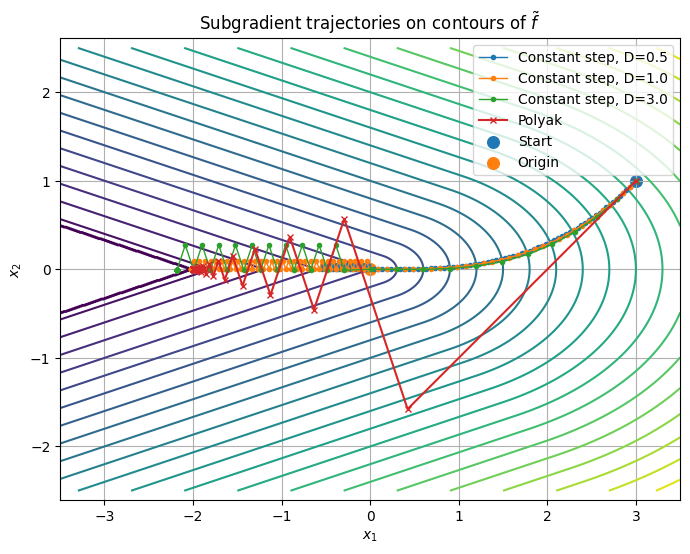

In [8]:
def run_polyak(T=100, x0=np.array([3.0, 1.0])):
    f_star = -1.0

    xs = [x0.copy()]
    values = [f_tilde_value(x0)]
    steps = []

    for _ in range(T):
        x = xs[-1].copy()
        g = subgrad_f_tilde(x)
        norm_g_sq = np.dot(g, g)

        if norm_g_sq == 0:
            h = 1.0
        else:
            h = (f_tilde_value(x) - f_star) / norm_g_sq

        x = x - h * g

        xs.append(x)
        values.append(f_tilde_value(x))
        steps.append(h)

    xs = np.array(xs)
    values = np.array(values)
    gaps = values - f_star
    best_gaps = np.minimum.accumulate(gaps)

    return xs, values, best_gaps, np.array(steps)


def f_tilde_grid(X1, X2):
    smooth_region = np.abs(X2) <= X1
    smooth_value = (X1**2 + 3 * X2**2)**0.5
    linear_value = (X1 + 3 * np.abs(X2)) / 2
    return np.maximum(np.where(smooth_region, smooth_value, linear_value), -1)


# Run Polyak method
xs_polyak, values_polyak, best_gaps_polyak, steps_polyak = run_polyak(T=100)

print(f"tilde f* = {-1}")
print(f"final x = {xs_polyak[-1]}")
print(f"final value = {values_polyak[-1]:.10f}")
print(f"final best gap = {best_gaps_polyak[-1]:.10e}")

# Graph 1: Polyak best optimality gap
plt.figure(figsize=(8, 5))
plt.plot(best_gaps_polyak)

plt.xlabel("Iteration t")
plt.ylabel(r"Best gap up to t")
plt.title(r"Polyak step-size subgradient method on $\tilde f$")
plt.grid(True)
plt.show()


# Graph 2: Trajectories on contour plot
x1_grid = np.linspace(-3.5, 3.5, 500)
x2_grid = np.linspace(-2.5, 2.5, 500)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = f_tilde_grid(X1, X2)

plt.figure(figsize=(8, 6))

plt.contour(X1, X2, Z, levels=25)
plt.contour(X1, X2, Z, levels=[-1], linewidths=2)

for D in D_estimates:
    xs, values, best_values = run_constant_step(D, T=100)
    plt.plot(
        xs[:, 0],
        xs[:, 1],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Constant step, D={D}"
    )

plt.plot(
    xs_polyak[:, 0],
    xs_polyak[:, 1],
    marker="x",
    markersize=4,
    linewidth=1.5,
    label="Polyak"
)

plt.scatter([3], [1], s=70, label="Start")
plt.scatter([0], [0], s=70, label="Origin")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Subgradient trajectories on contours of $\tilde f$")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()